# Etapa 6 — Interpretabilidade (XAI): RF e XGBoost — Estado Operacional

**Modelos analisados:** RF e XGBoost da **Abordagem 2** (17 classes — Estado Operacional)

Duas técnicas complementares:

1. **Feature Importance MDI** — ranking nativo dos modelos de árvore: instantâneo, mas tende a superestimar features contínuas.
2. **SHAP (SHapley Additive exPlanations)** — padrão-ouro de XAI: atribui a cada feature sua contribuição marginal e justa para cada predição. Mais lento, mas correto.

Foco especial nas **classes mais difíceis**:
- **Classe 7 (PCK Incrustação Ativo):** RF F1=0.009 vs XGBoost F1=0.571 — por que a diferença?
- **Classe 102 (DHSV Transiente):** segunda classe mais difícil para ambos os modelos

In [7]:
import sys
sys.path.insert(0, '..')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from config import WINDOW_CLASSES, FEATURES_WINDOW_PATH, FIGURES_DIR, MODELS_DIR

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
shap.initjs()
print('Bibliotecas carregadas!')

Bibliotecas carregadas!


## 6.1 Carregar modelos e dados — Abordagem 2 (17 classes)

In [8]:
df2 = pd.read_parquet(FEATURES_WINDOW_PATH)
META_COLS = ['instance_id', 'fault_class', 'window_label', 'source_type', 'window_start']
feature_cols = [c for c in df2.columns if c not in META_COLS]

# Imputadores e modelos já treinados — usa transform(), nunca fit_transform()
imp  = joblib.load(MODELS_DIR / 'imputer_window_class.joblib')
le   = joblib.load(MODELS_DIR / 'label_encoder_window_class.joblib')
rf   = joblib.load(MODELS_DIR / 'rf_window_class.joblib')
xgb  = joblib.load(MODELS_DIR / 'xgboost_window_class.joblib')

X = imp.transform(df2[feature_cols].values)
y = df2['window_label'].values          # labels originais: 0, 1-9, 101-109

classes      = le.classes_              # labels originais ordenados
class_names  = [WINDOW_CLASSES.get(c, str(c)) for c in classes]
orig_to_idx  = {orig: idx for idx, orig in enumerate(classes)}

print(f'Janelas: {X.shape[0]:,} | Features: {X.shape[1]} | Classes: {len(classes)}')
print(f'Classes: {classes.tolist()}')
print(f'\nÍndice classe 7   (PCK Incrust. Ativo): {orig_to_idx[7]}')
print(f'Índice classe 102 (DHSV Trans.):        {orig_to_idx[102]}')

Janelas: 449,397 | Features: 88 | Classes: 17
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 101, 102, 105, 106, 107, 108, 109]

Índice classe 7   (PCK Incrust. Ativo): 7
Índice classe 102 (DHSV Trans.):        11


In [9]:
def sensor_importance(shap_explanation, feature_names):
    """Agrega mean|SHAP| por sensor (soma das 11 estatísticas de cada sensor)."""
    sensors = ['P-PDG', 'T-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'QGL']
    mean_abs        = np.abs(shap_explanation.values).mean(axis=0)   # (n_features, n_classes)
    mean_abs_global = mean_abs.mean(axis=-1)                          # (n_features,)
    feat_imp = pd.Series(mean_abs_global, index=feature_names)
    sensor_imp = {}
    for s in sensors:
        cols = [c for c in feature_names if c.startswith(s + '_')]
        sensor_imp[s] = feat_imp[cols].sum()
    return pd.Series(sensor_imp).sort_values(ascending=True)

## 6.2 Feature Importance MDI — RF vs XGBoost

O MDI mede quantas vezes cada feature foi usada nas árvores e o quanto ela reduziu a impureza.
Valores maiores = feature mais usada e mais discriminativa.

**Limitação:** tende a superestimar features contínuas de alta cardinalidade. Usado como baseline antes do SHAP.

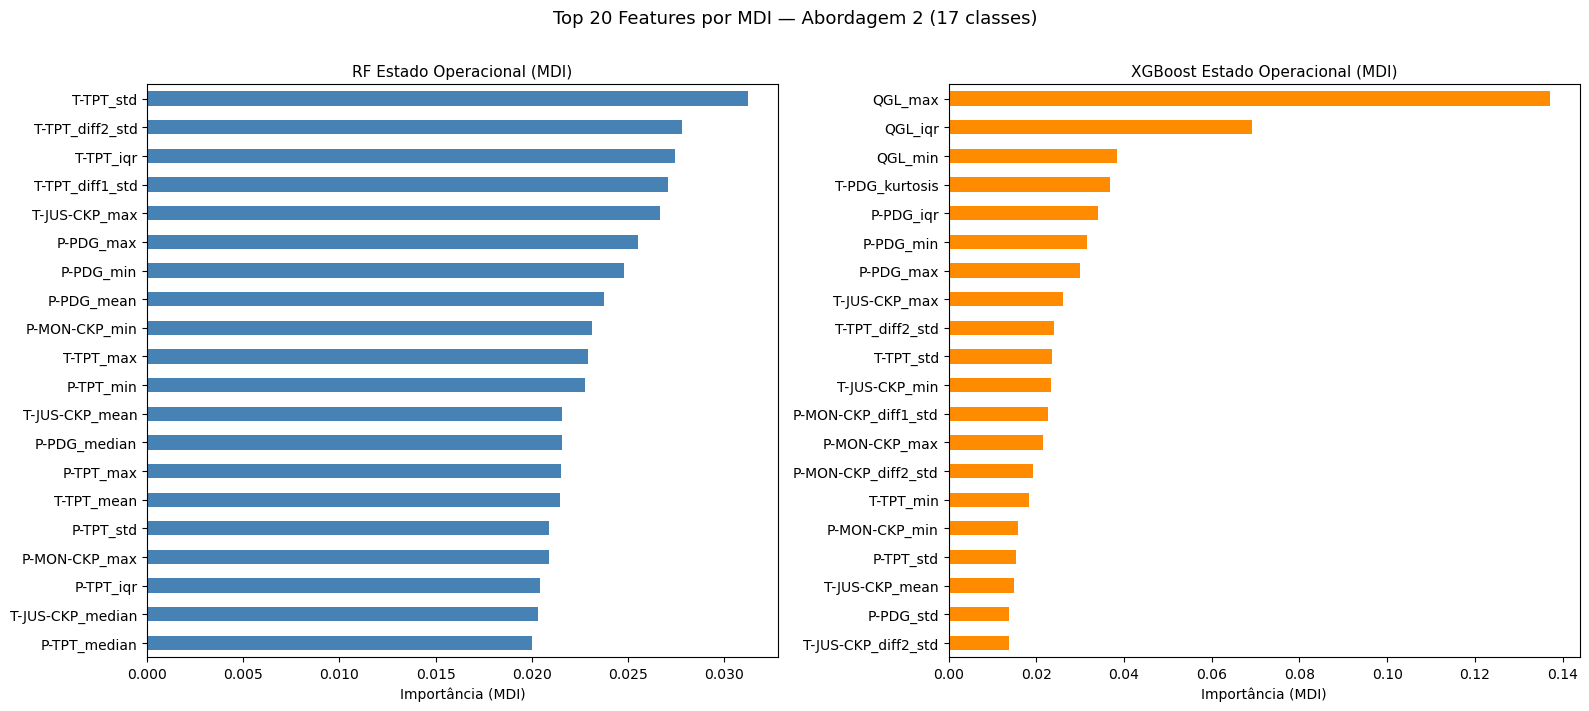

In [10]:
imp_rf  = pd.Series(rf.feature_importances_,  index=feature_cols)
imp_xgb = pd.Series(xgb.feature_importances_, index=feature_cols)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, imp_vals, title, color in zip(
    axes,
    [imp_rf, imp_xgb],
    ['RF Estado Operacional (MDI)', 'XGBoost Estado Operacional (MDI)'],
    ['steelblue', 'darkorange'],
):
    top = imp_vals.sort_values(ascending=False).head(20)
    top.sort_values().plot(kind='barh', ax=ax, color=color)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Importância (MDI)')

plt.suptitle('Top 20 Features por MDI — Abordagem 2 (17 classes)', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'mdi_rf_xgb_estado_operacional.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3 SHAP Global — RF Estado Operacional\n",
    "\n",
    "**TreeExplainer** calcula SHAP de forma exata para modelos baseados em árvores.\n",
    "\n",
    "**Amostragem balanceada:** usamos o mesmo número de janelas por classe (N = tamanho da menor classe).\n",
    "Isso garante que classes raras como a classe 7 (914 janelas) sejam representadas tão bem\n",
    "quanto classes majoritárias — essencial para comparar SHAP entre classes de forma justa.\n",
    "\n",
    "⏳ Esta célula leva ~5–8 minutos (15k janelas × 17 classes).

N por classe disponível: 914 | Usado: 50 | Total: 850
Amostra balanceada: 850 janelas
Verificação — janelas por classe: {0: 50, 1: 50, 2: 50, 3: 50, 4: 50, 5: 50, 6: 50, 7: 50, 8: 50, 9: 50, 101: 50, 102: 50, 105: 50, 106: 50, 107: 50, 108: 50, 109: 50}
Calculando SHAP — RF (estimativa: 20-30 min)...
SHAP RF calculado. Shape: (850, 88, 17)


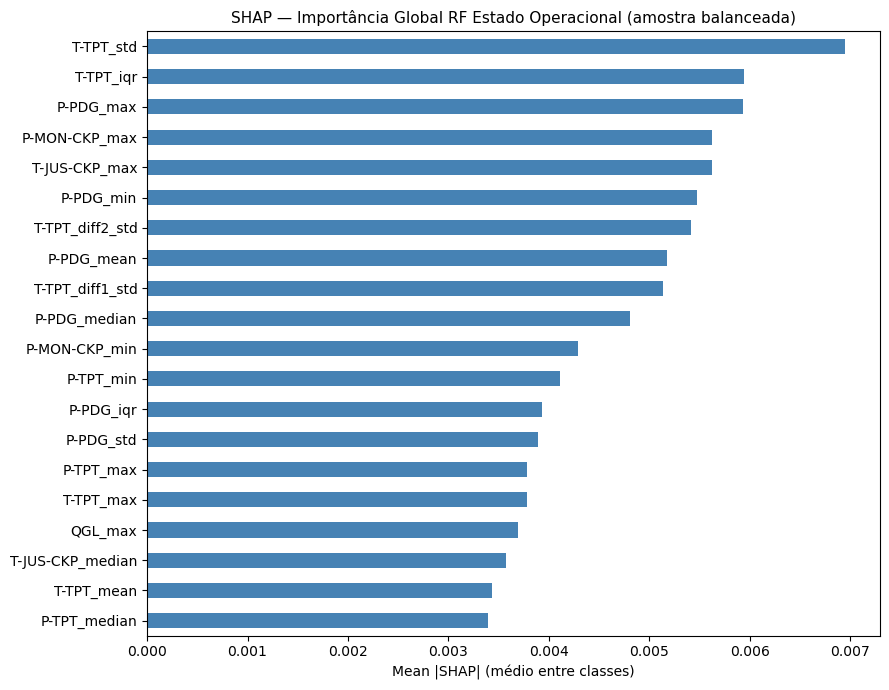

In [11]:
rng = np.random.default_rng(42)

# RF tem max_depth=None -> árvores de profundidade ~42.
# TreeSHAP é O(amostras x árvores x profundidade²): com 15k amostras ~10h.
# 50/classe (850 total) dá padrões estáveis em ~20-30 min.
N_SHAP_PER_CLASS = 50
n_per_class_full = min(int(np.sum(y == c)) for c in np.unique(y))  # 914 (classe 7)
n_per_class = min(n_per_class_full, N_SHAP_PER_CLASS)
print(f"N por classe disponível: {n_per_class_full} | Usado: {n_per_class} | "
      f"Total: {n_per_class * len(np.unique(y)):,}")

idx_balanced = np.concatenate([
    rng.choice(np.where(y == c)[0], n_per_class, replace=False)
    for c in np.unique(y)
])
rng.shuffle(idx_balanced)

X_sample = pd.DataFrame(X[idx_balanced], columns=feature_cols)
y_sample  = y[idx_balanced]

print(f"Amostra balanceada: {len(X_sample):,} janelas")
print(f"Verificação — janelas por classe: {pd.Series(y_sample).value_counts().sort_index().to_dict()}")

print("Calculando SHAP — RF (estimativa: 20-30 min)...")
explainer_rf = shap.TreeExplainer(rf)
shap_rf      = explainer_rf(X_sample)        # shape: (850, 88, 17)
print(f"SHAP RF calculado. Shape: {shap_rf.shape}")

# shap.plots.bar tem bug com multiclasse em algumas versões do SHAP;
# barplot manual com mean|SHAP| médio entre classes é equivalente.
mean_abs_rf = np.abs(shap_rf.values).mean(axis=(0, 2))  # (88,)
feat_imp_rf = pd.Series(mean_abs_rf, index=feature_cols)
top20_rf    = feat_imp_rf.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
top20_rf.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Mean |SHAP| (médio entre classes)")
ax.set_title("SHAP — Importância Global RF Estado Operacional (amostra balanceada)", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_bar_rf_estado_operacional.png", dpi=150, bbox_inches="tight")
plt.show()


## 6.4 SHAP por Sensor — RF vs XGBoost

As 88 features vêm de 8 sensores × 11 estatísticas. Agregando a importância por sensor respondemos:
**qual sensor físico é mais informativo para classificar o estado operacional?**

⏳ Esta célula leva ~2–3 minutos (calcula SHAP do XGBoost).

Calculando SHAP — XGBoost...
SHAP XGBoost calculado. Shape: (850, 88, 17)


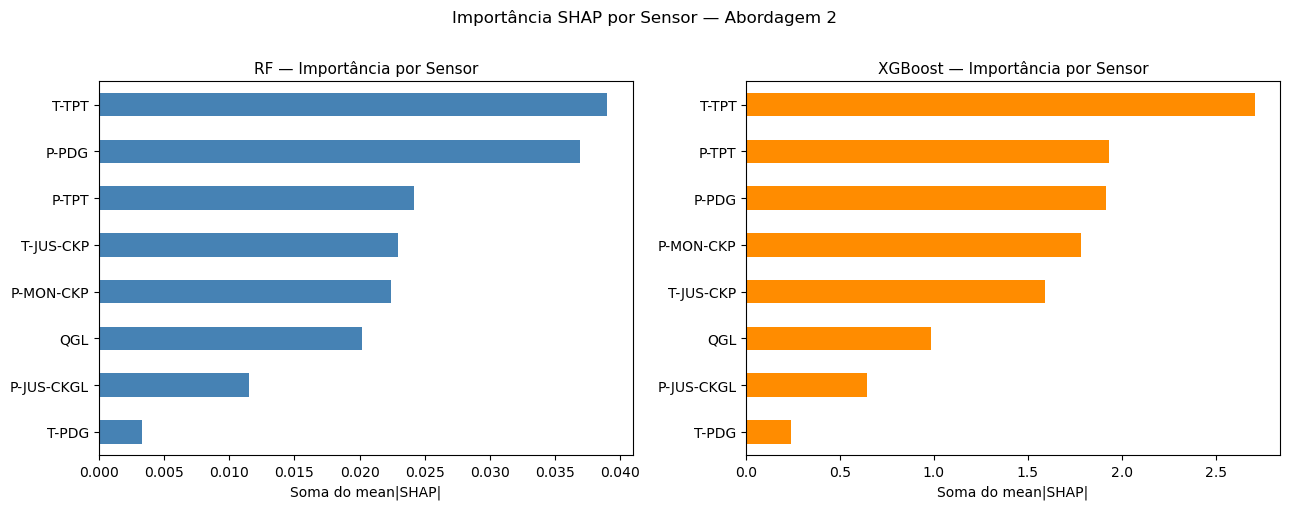


Importância por sensor (mean|SHAP| acumulado):
                  RF   XGBoost
P-JUS-CKGL  0.011511  0.642869
P-MON-CKP   0.022391  1.784533
P-PDG       0.036900  1.918185
P-TPT       0.024196  1.929602
QGL         0.020191  0.986289
T-JUS-CKP   0.022961  1.593106
T-PDG       0.003306  0.240294
T-TPT       0.039004  2.706317


In [12]:
print('Calculando SHAP — XGBoost...')
explainer_xgb = shap.TreeExplainer(xgb)
shap_xgb      = explainer_xgb(X_sample)      # shape: (850, 88, 17)
print(f'SHAP XGBoost calculado. Shape: {shap_xgb.shape}')

sensor_rf  = sensor_importance(shap_rf,  feature_cols)
sensor_xgb = sensor_importance(shap_xgb, feature_cols)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sensor_rf.plot(kind='barh',  ax=axes[0], color='steelblue')
axes[0].set_title('RF — Importância por Sensor', fontsize=11)
axes[0].set_xlabel('Soma do mean|SHAP|')

sensor_xgb.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('XGBoost — Importância por Sensor', fontsize=11)
axes[1].set_xlabel('Soma do mean|SHAP|')

plt.suptitle('Importância SHAP por Sensor — Abordagem 2', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'shap_por_sensor_estado_operacional.png', dpi=150, bbox_inches='tight')
plt.show()

df_sensor = pd.DataFrame({
    'RF':      sensor_rf.sort_values(ascending=False),
    'XGBoost': sensor_xgb.sort_values(ascending=False),
})
print('\nImportância por sensor (mean|SHAP| acumulado):')
print(df_sensor.to_string())

## 6.5 SHAP — Classe 7: PCK Incrustação Ativo

Esta é a análise mais importante: por que o **RF ignora essa classe** (F1=0.009) e o **XGBoost
consegue detectá-la parcialmente** (F1=0.571)?

Se o RF mostra valores SHAP próximos de zero para todas as features, o modelo simplesmente
optou por nunca predizer essa classe — o desbalanceamento (914 janelas em 449k) dominou.
O XGBoost, com seu mecanismo de boosting sequencial, consegue focar nos erros residuais
dessa classe minoritária e encontrar features discriminativas.

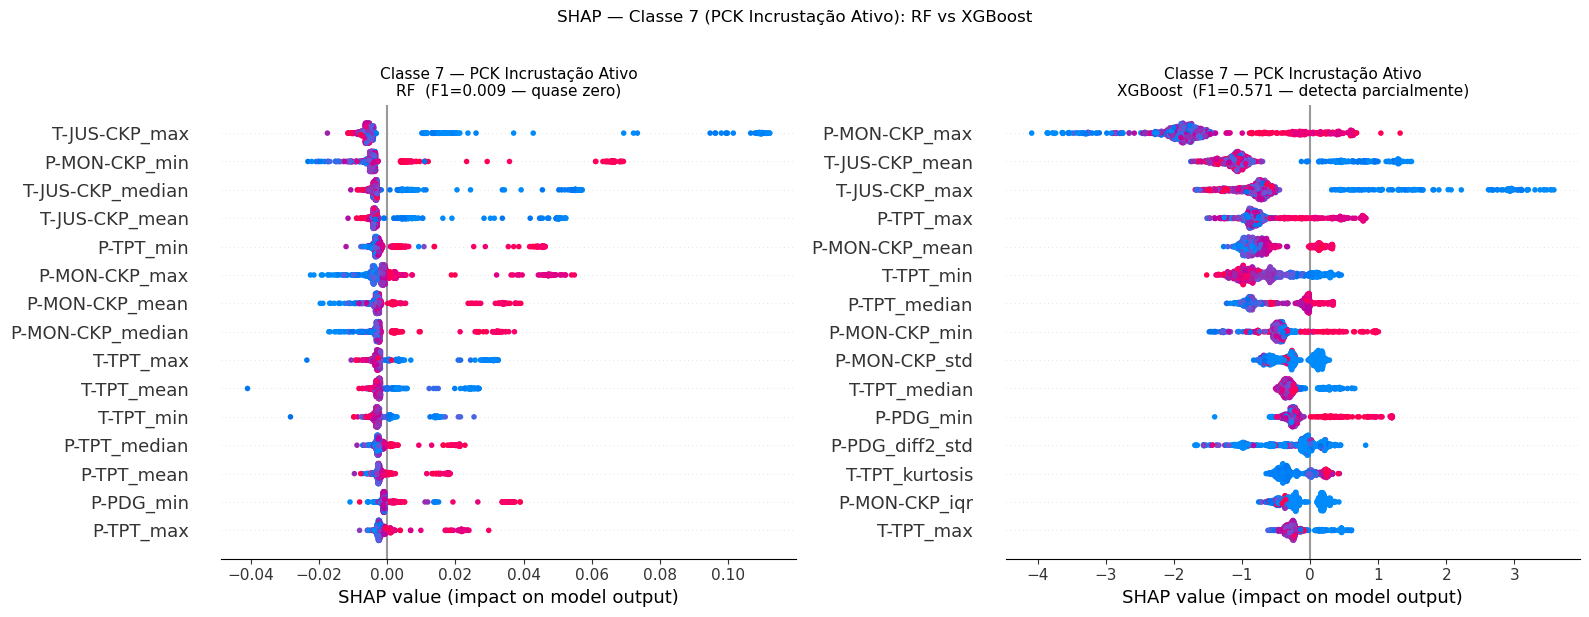

In [13]:
idx_c7   = orig_to_idx[7]
idx_c102 = orig_to_idx[102]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, sv, title in zip(
    axes,
    [shap_rf[:, :, idx_c7], shap_xgb[:, :, idx_c7]],
    ['RF  (F1=0.009 — quase zero)', 'XGBoost  (F1=0.571 — detecta parcialmente)'],
):
    plt.sca(ax)
    shap.summary_plot(
        sv.values if hasattr(sv, 'values') else sv,
        X_sample,
        feature_names=feature_cols,
        max_display=15,
        show=False,
        plot_size=None,
        color_bar=False,
    )
    ax.set_title(f'Classe 7 — PCK Incrustação Ativo\n{title}', fontsize=11)

plt.suptitle('SHAP — Classe 7 (PCK Incrustação Ativo): RF vs XGBoost', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'shap_classe7_rf_vs_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.6 SHAP — Classe 102: DHSV Transiente

Fase transiente do fechamento espúrio da DHSV (válvula de segurança de fundo).
RF: F1=0.786 | XGBoost: F1=0.828

As features que distinguem o transiente (classe 102) do estado ativo (classe 2)
devem refletir a dinâmica de pressão antes do fechamento completo da válvula.

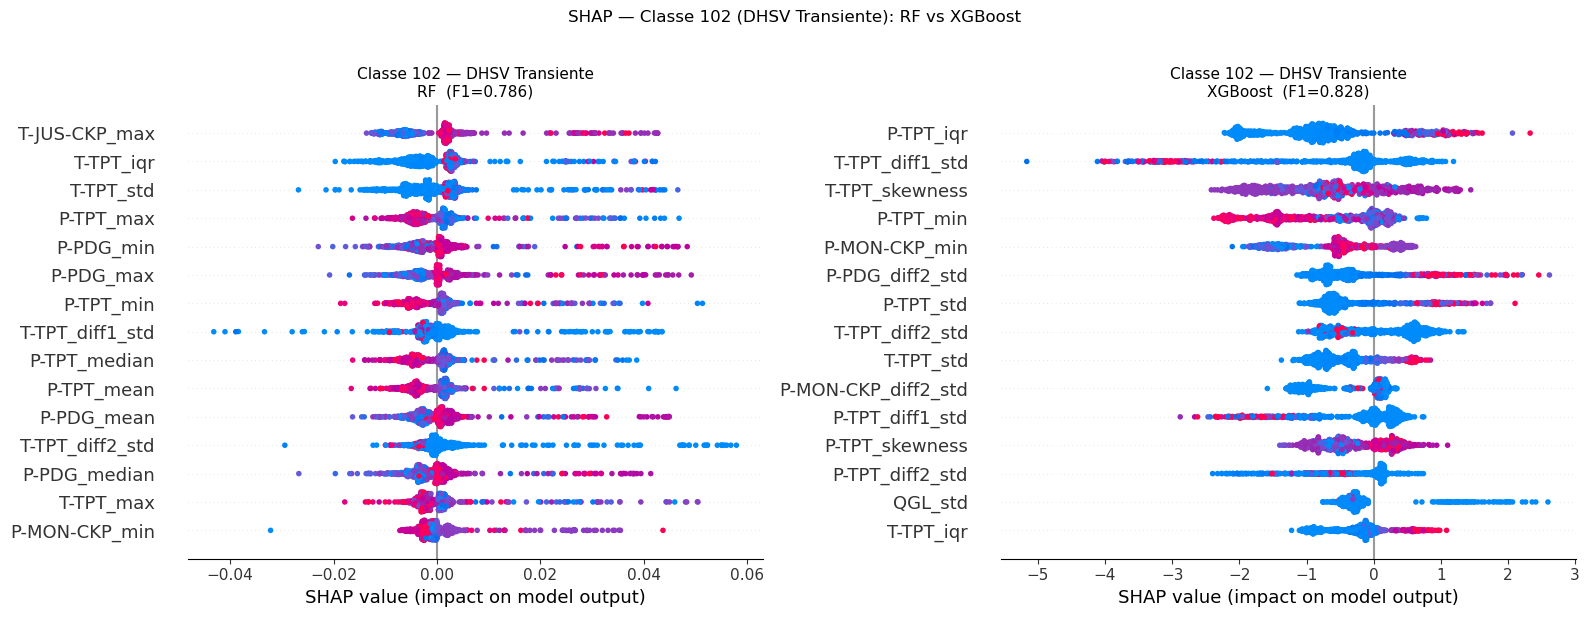

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, sv, title in zip(
    axes,
    [shap_rf[:, :, idx_c102], shap_xgb[:, :, idx_c102]],
    ['RF  (F1=0.786)', 'XGBoost  (F1=0.828)'],
):
    plt.sca(ax)
    shap.summary_plot(
        sv.values if hasattr(sv, 'values') else sv,
        X_sample,
        feature_names=feature_cols,
        max_display=15,
        show=False,
        plot_size=None,
        color_bar=False,
    )
    ax.set_title(f'Classe 102 — DHSV Transiente\n{title}', fontsize=11)

plt.suptitle('SHAP — Classe 102 (DHSV Transiente): RF vs XGBoost', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'shap_classe102_rf_vs_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.7 SHAP — Todas as Classes: RF vs XGBoost

Plots comparativos para as 17 classes da Abordagem 2.
Cada figura salva em .

**Como ler:** eixo X = valor SHAP para aquela classe (positivo = empurra para a classe,
negativo = afasta); cor da feature = vermelho (valor alto) / azul (valor baixo); cada ponto = uma janela.


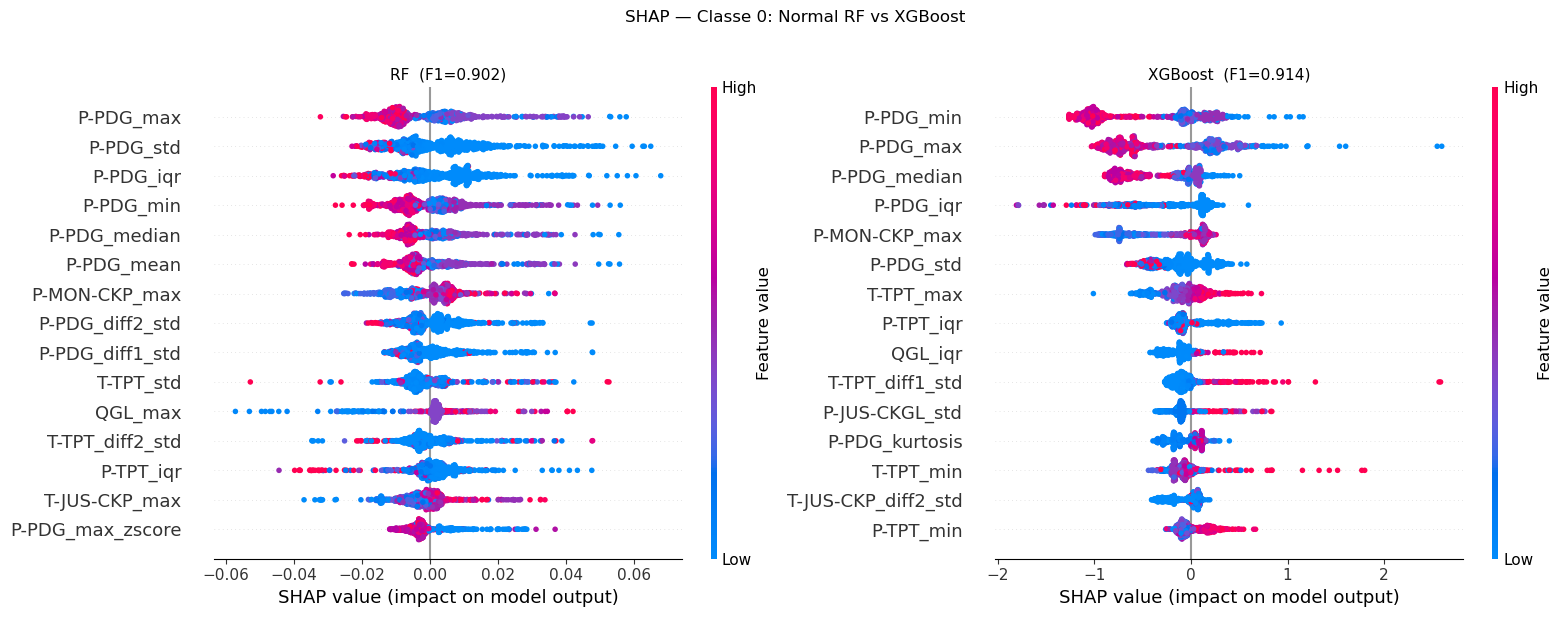

Classe    0 (Normal                      ) RF=0.902  XGB=0.914  -> shap_classe0_rf_vs_xgboost.png


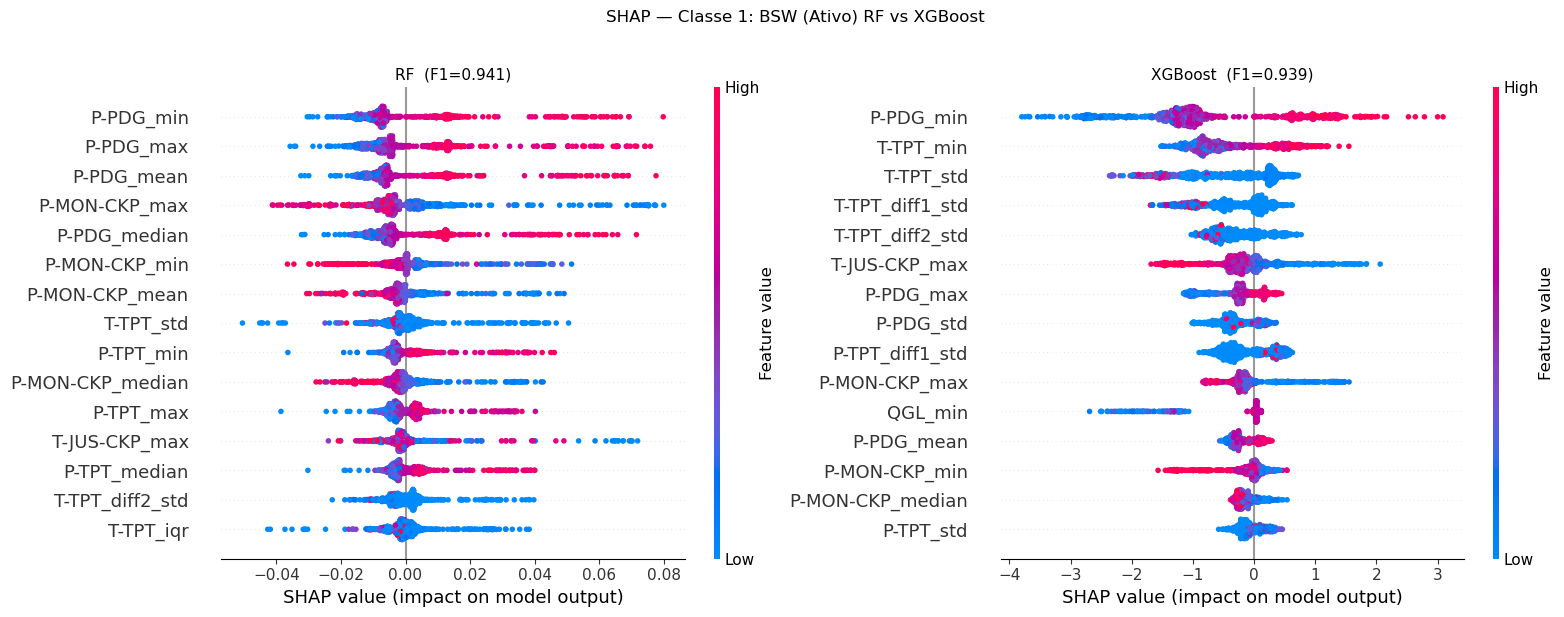

Classe    1 (BSW (Ativo)                 ) RF=0.941  XGB=0.939  -> shap_classe1_rf_vs_xgboost.png


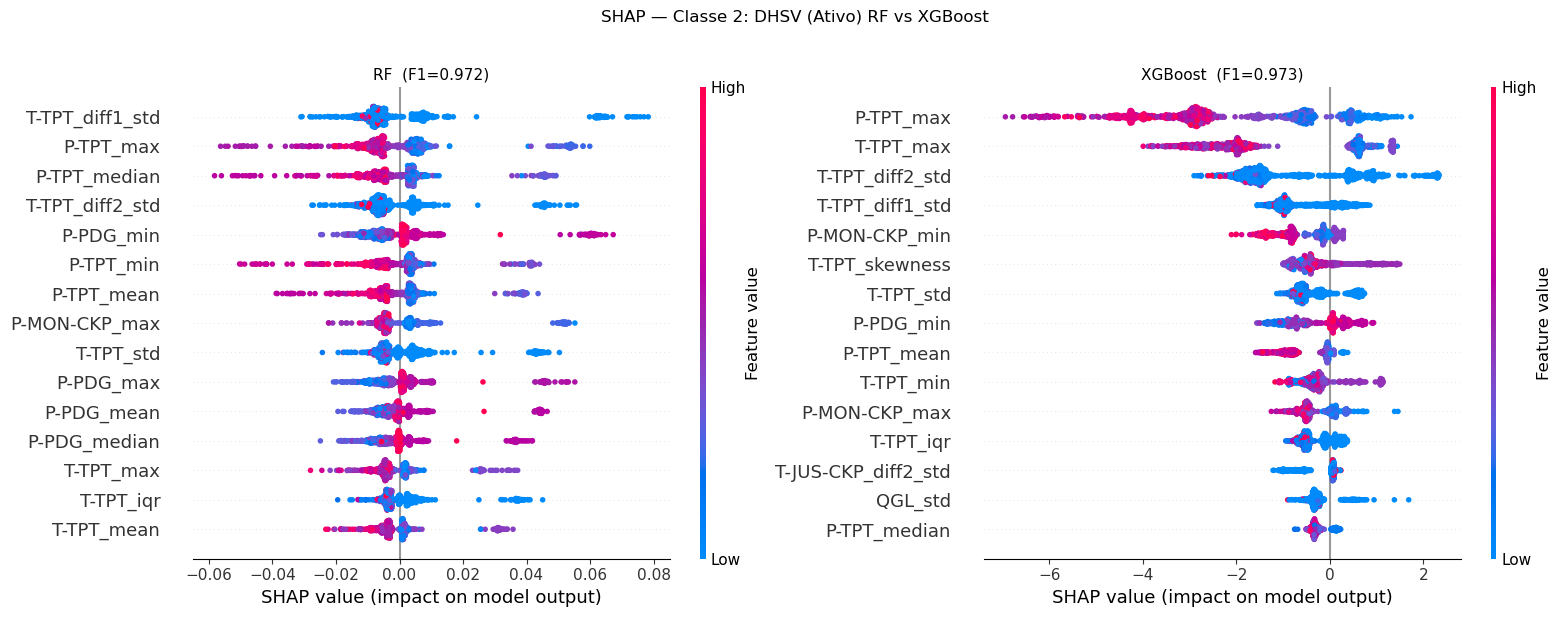

Classe    2 (DHSV (Ativo)                ) RF=0.972  XGB=0.973  -> shap_classe2_rf_vs_xgboost.png


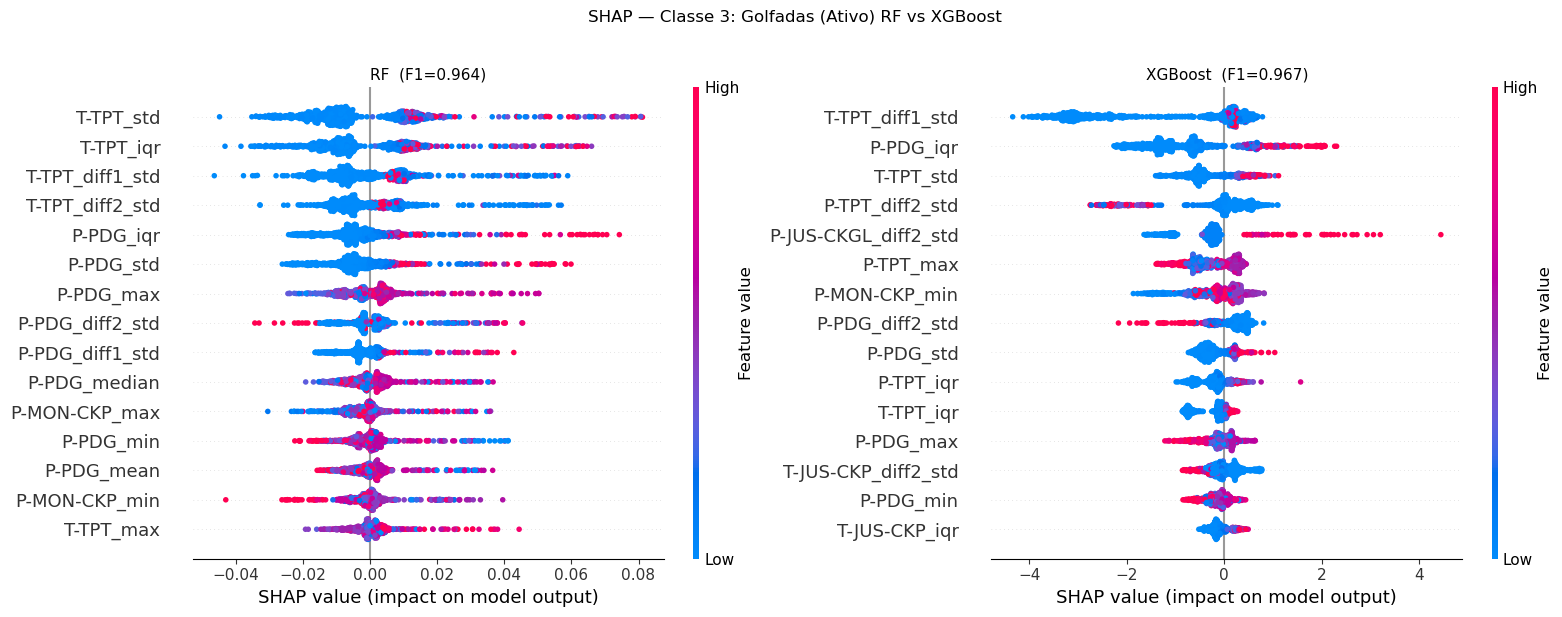

Classe    3 (Golfadas (Ativo)            ) RF=0.964  XGB=0.967  -> shap_classe3_rf_vs_xgboost.png


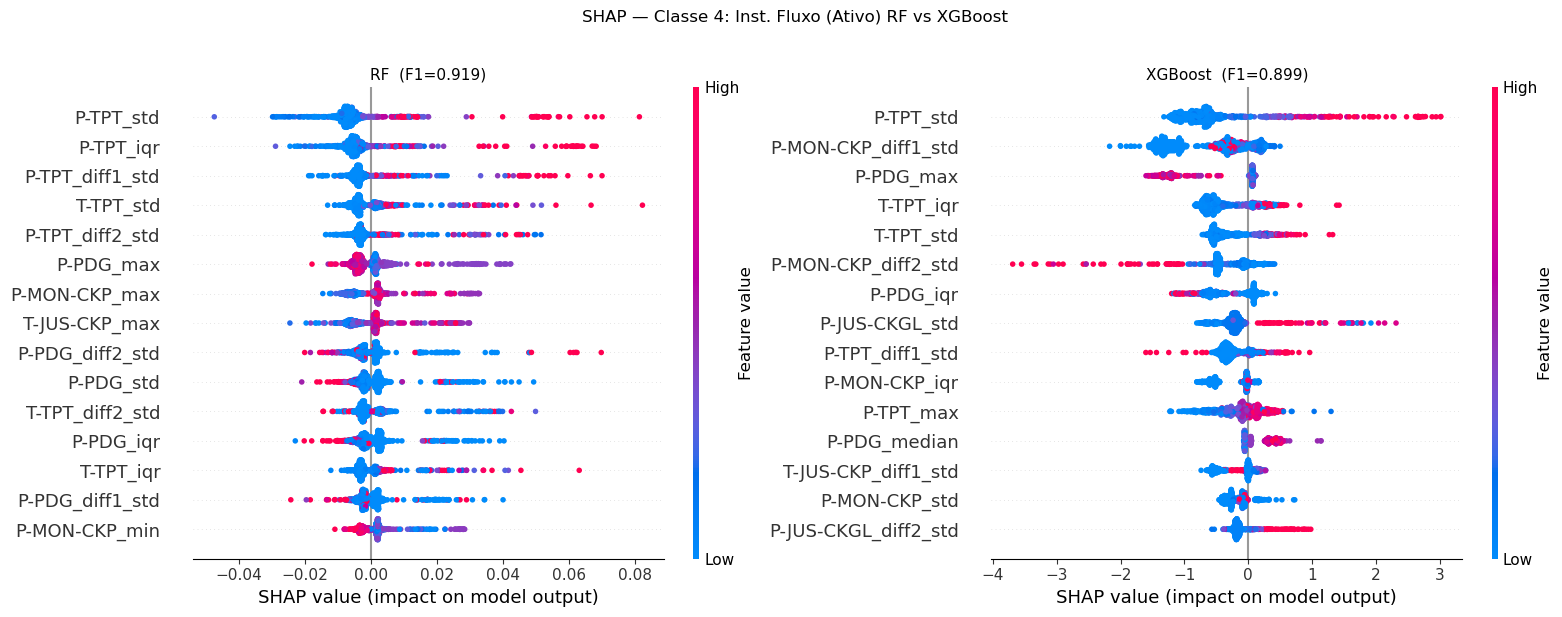

Classe    4 (Inst. Fluxo (Ativo)         ) RF=0.919  XGB=0.899  -> shap_classe4_rf_vs_xgboost.png


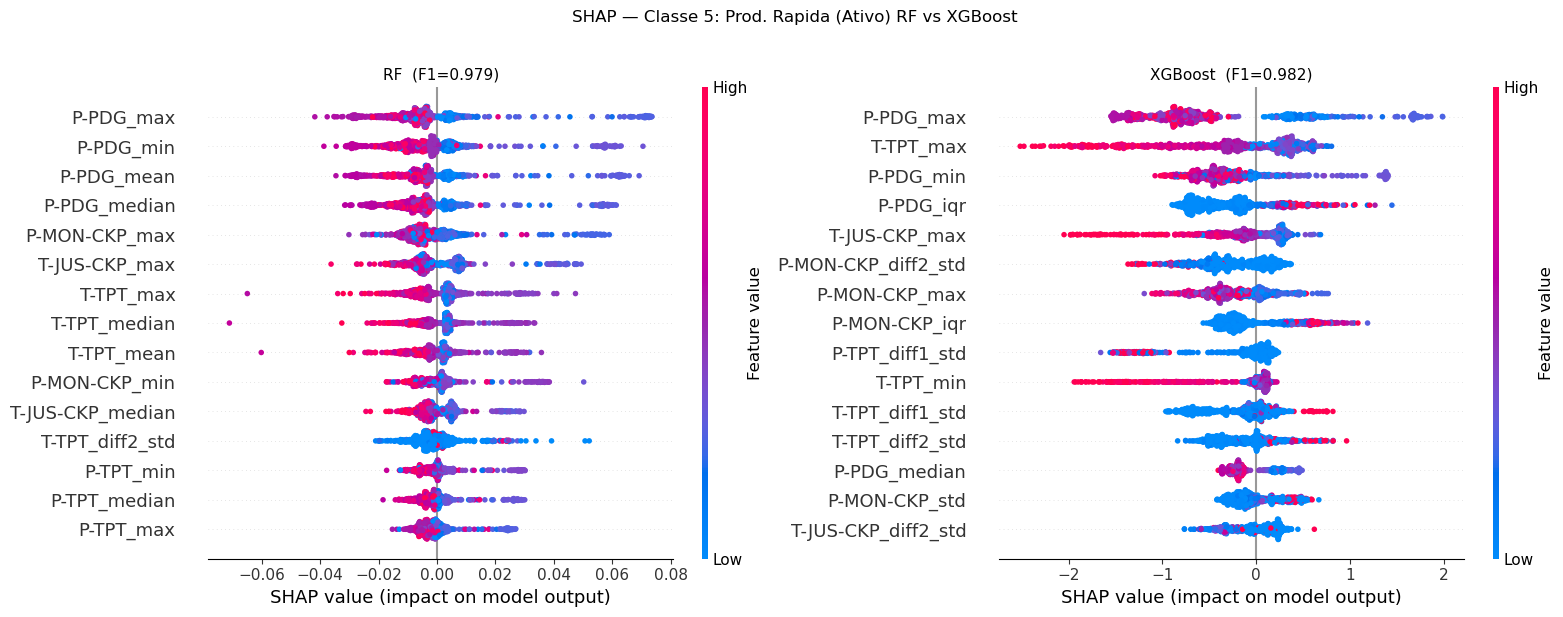

Classe    5 (Prod. Rapida (Ativo)        ) RF=0.979  XGB=0.982  -> shap_classe5_rf_vs_xgboost.png


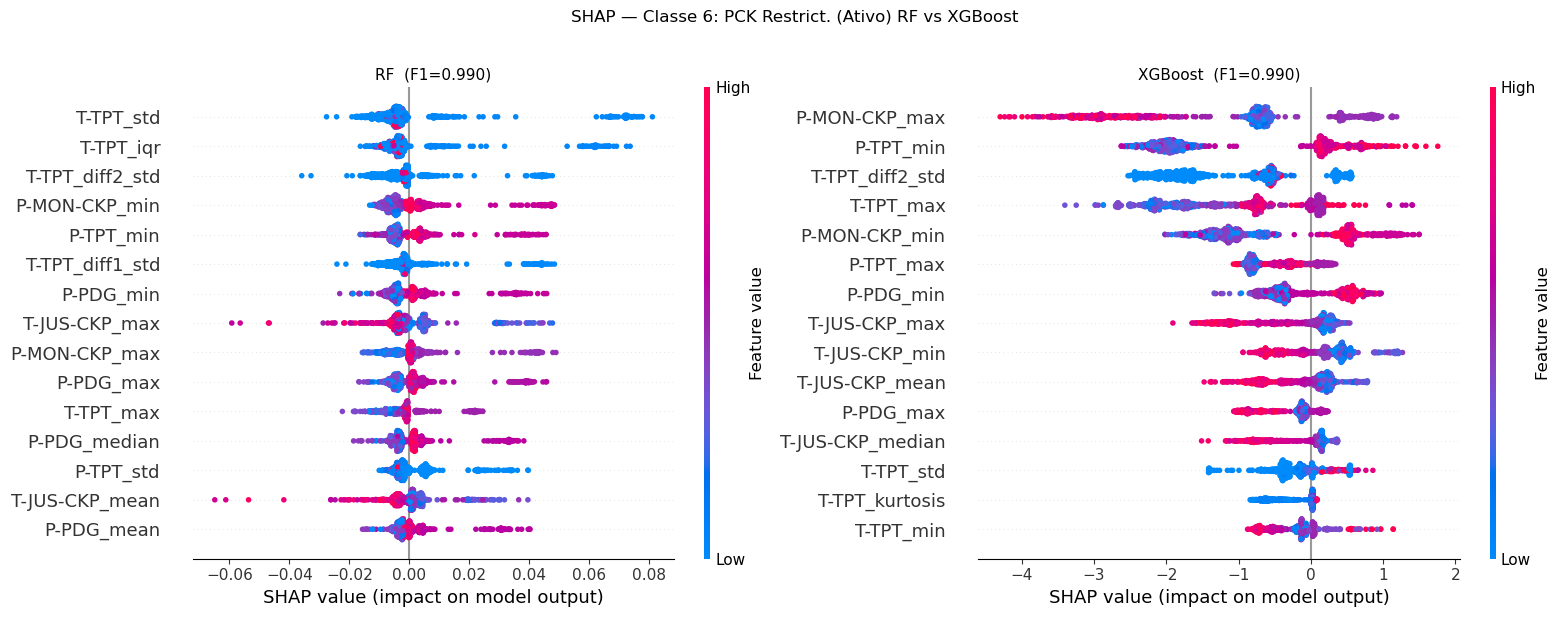

Classe    6 (PCK Restrict. (Ativo)       ) RF=0.990  XGB=0.990  -> shap_classe6_rf_vs_xgboost.png


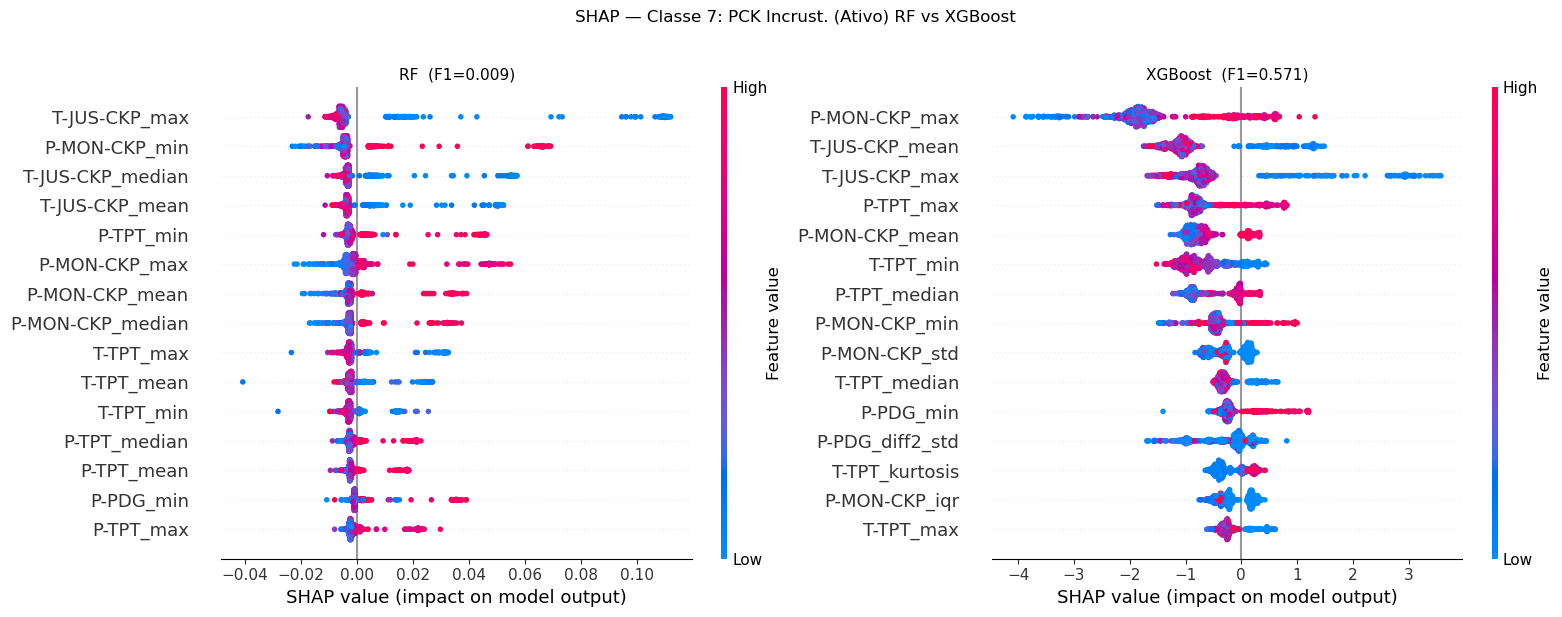

Classe    7 (PCK Incrust. (Ativo)        ) RF=0.009  XGB=0.571  -> shap_classe7_rf_vs_xgboost.png


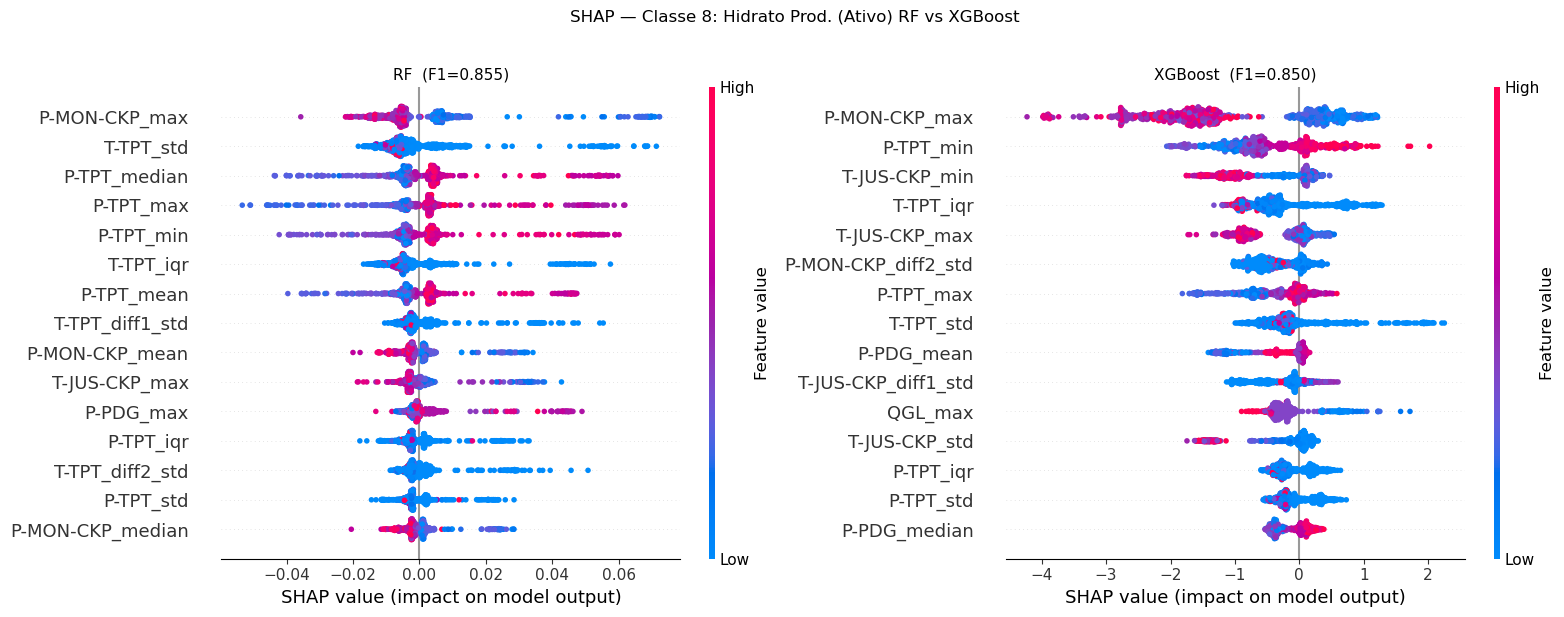

Classe    8 (Hidrato Prod. (Ativo)       ) RF=0.855  XGB=0.850  -> shap_classe8_rf_vs_xgboost.png


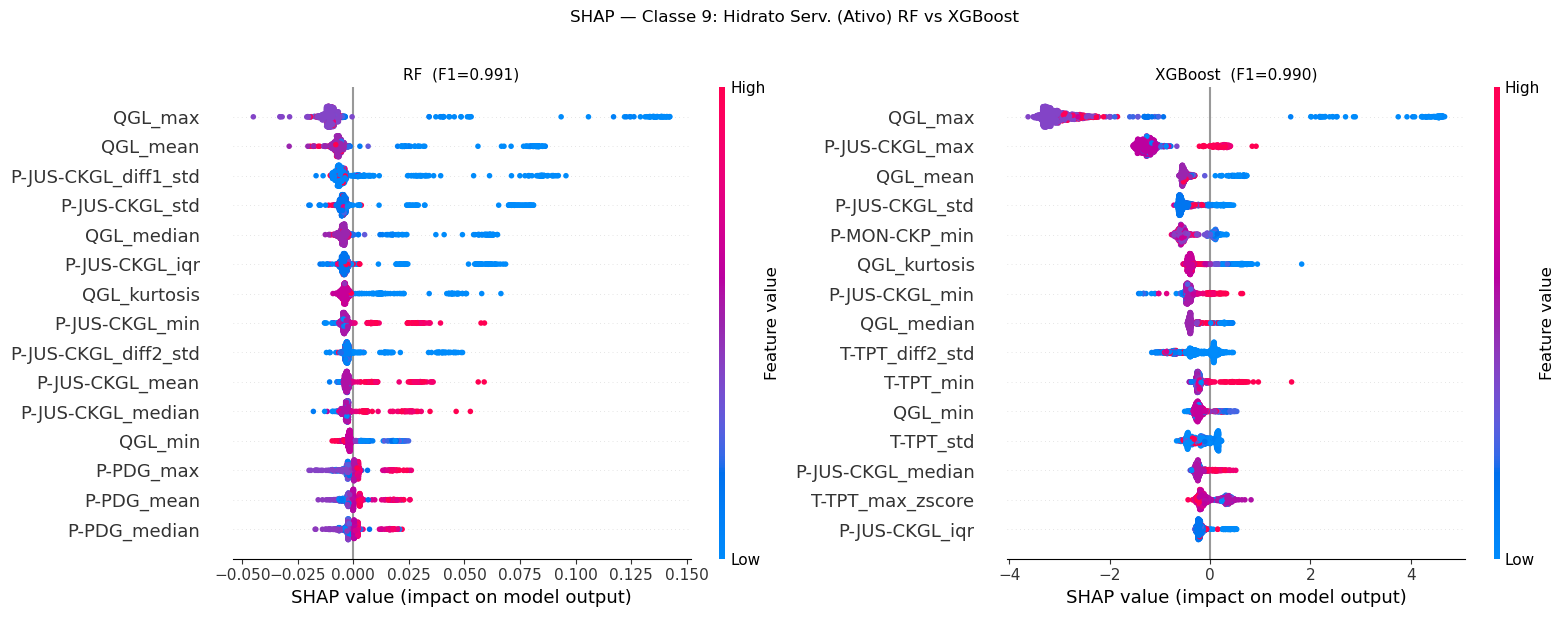

Classe    9 (Hidrato Serv. (Ativo)       ) RF=0.991  XGB=0.990  -> shap_classe9_rf_vs_xgboost.png


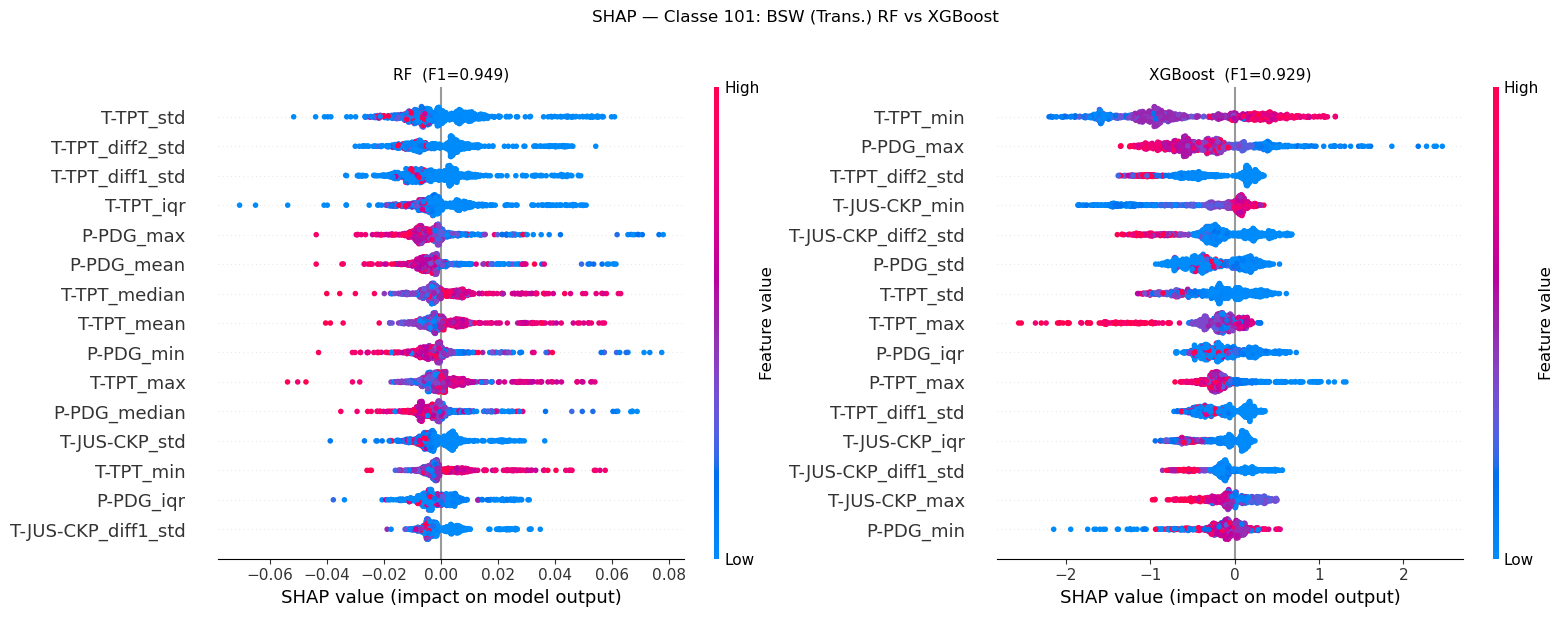

Classe  101 (BSW (Trans.)                ) RF=0.949  XGB=0.929  -> shap_classe101_rf_vs_xgboost.png


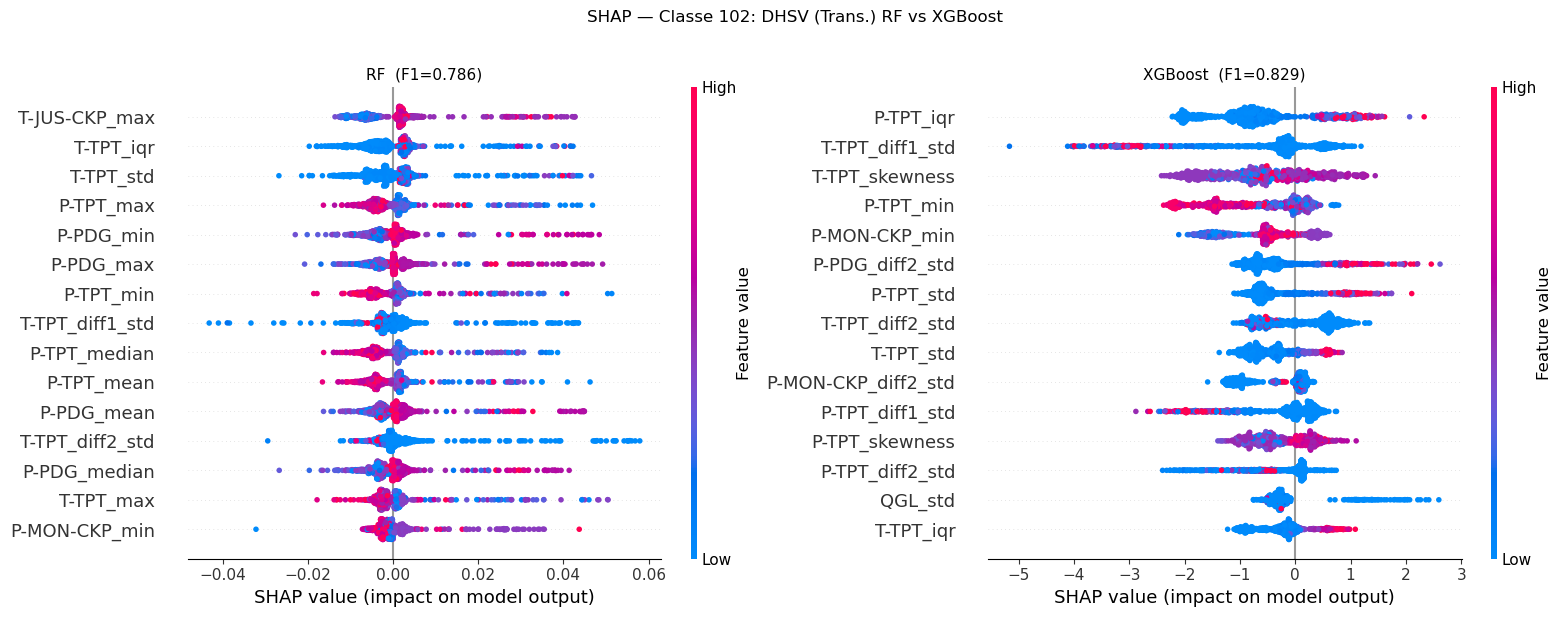

Classe  102 (DHSV (Trans.)               ) RF=0.786  XGB=0.829  -> shap_classe102_rf_vs_xgboost.png


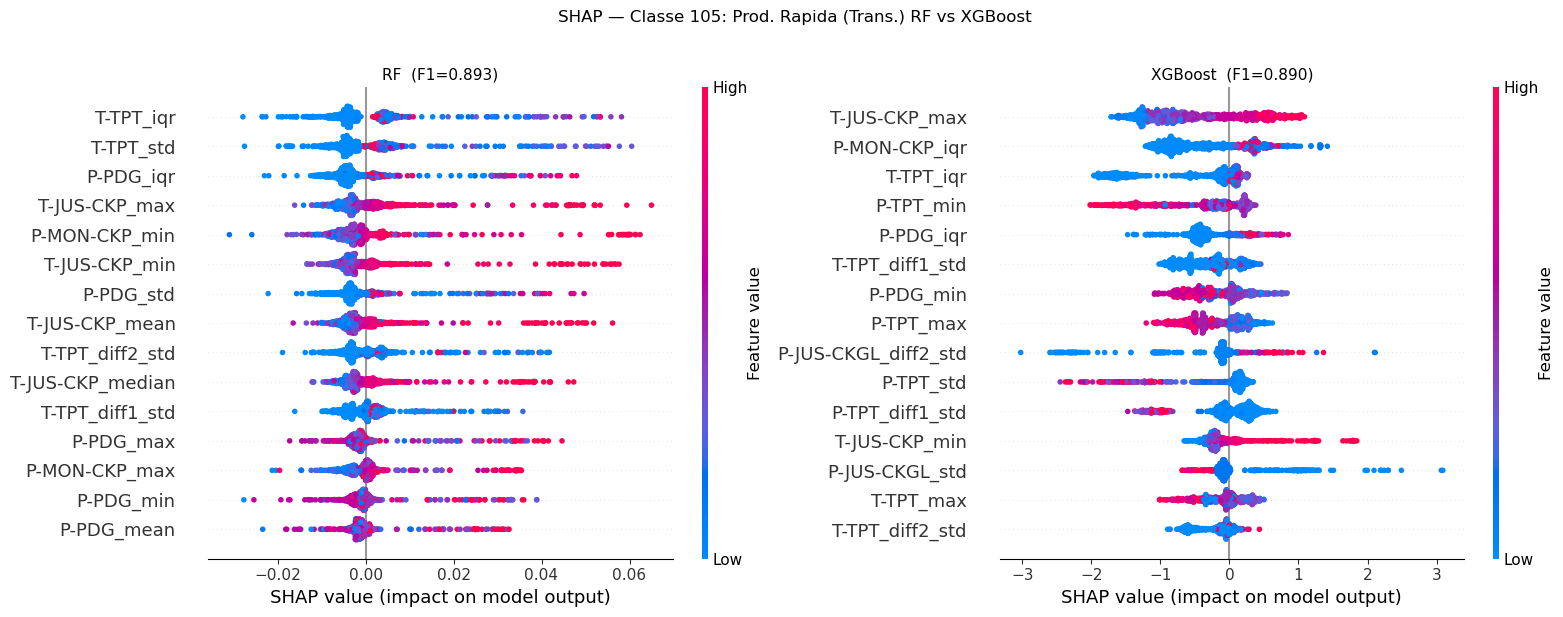

Classe  105 (Prod. Rapida (Trans.)       ) RF=0.893  XGB=0.890  -> shap_classe105_rf_vs_xgboost.png


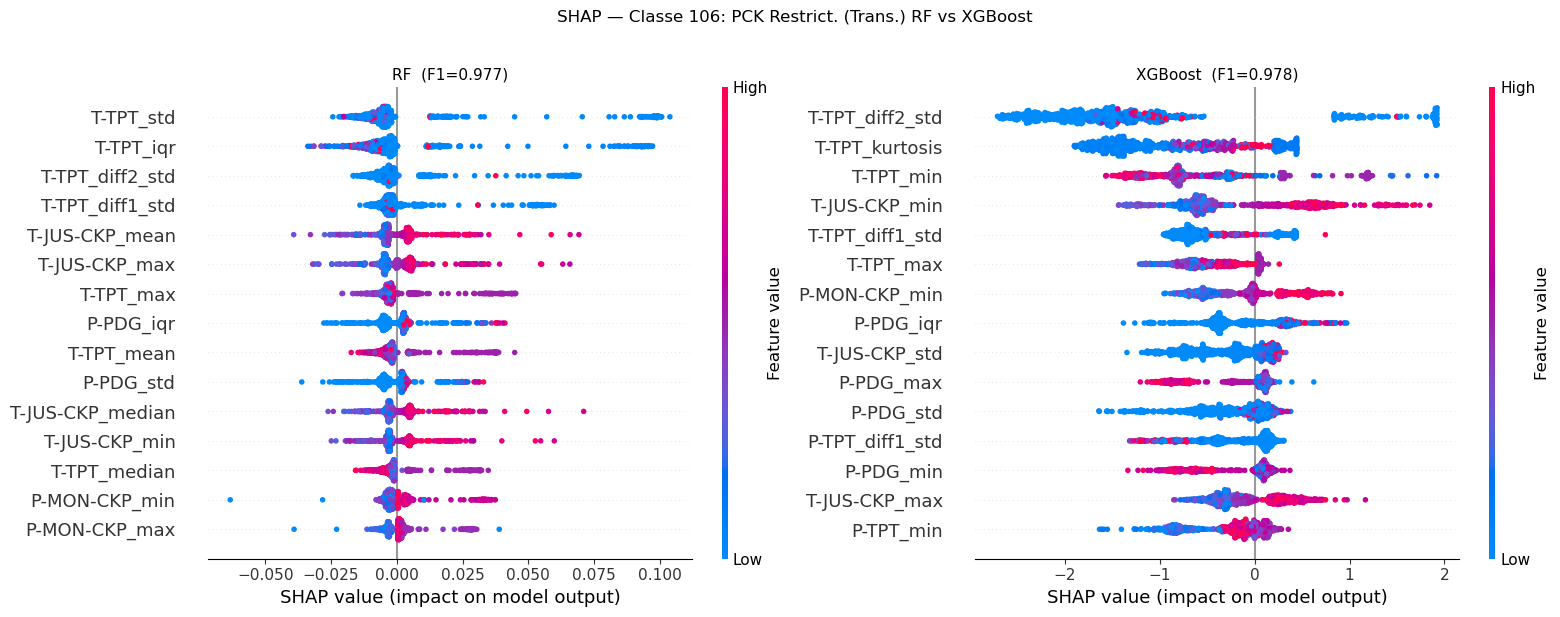

Classe  106 (PCK Restrict. (Trans.)      ) RF=0.977  XGB=0.978  -> shap_classe106_rf_vs_xgboost.png


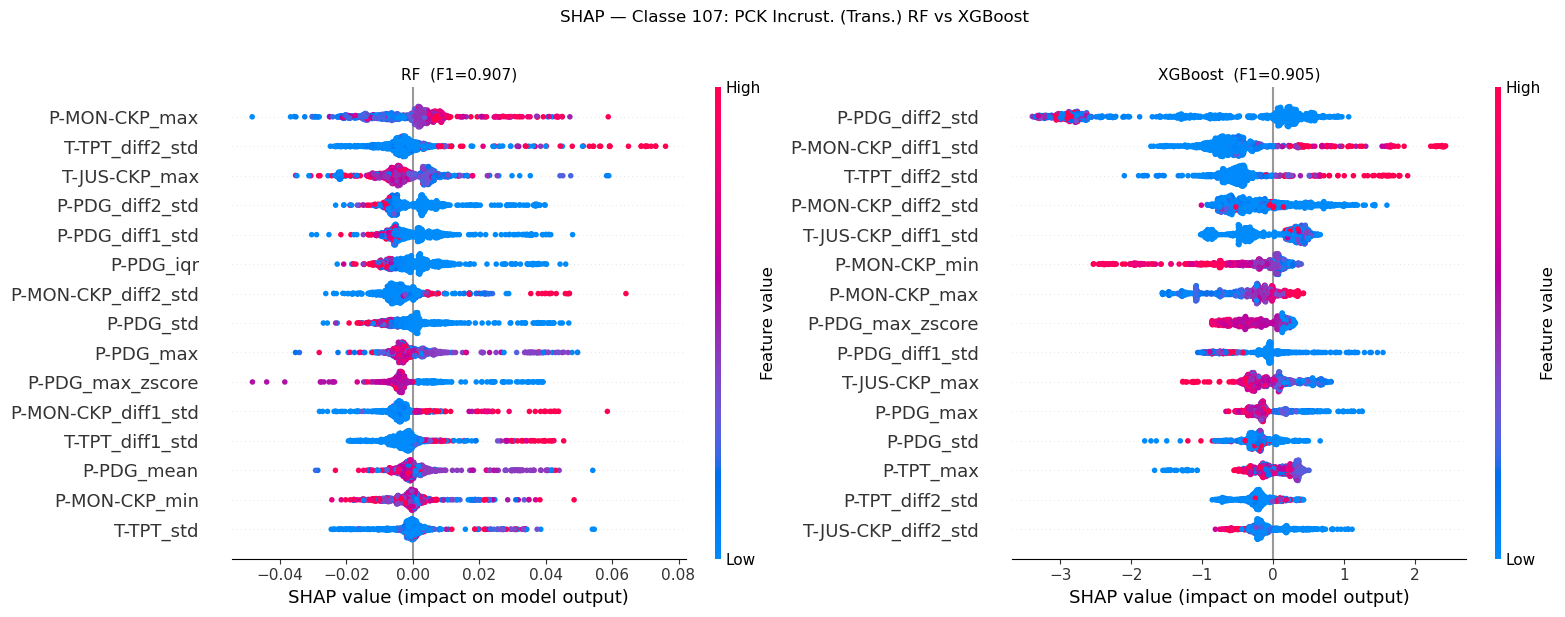

Classe  107 (PCK Incrust. (Trans.)       ) RF=0.907  XGB=0.905  -> shap_classe107_rf_vs_xgboost.png


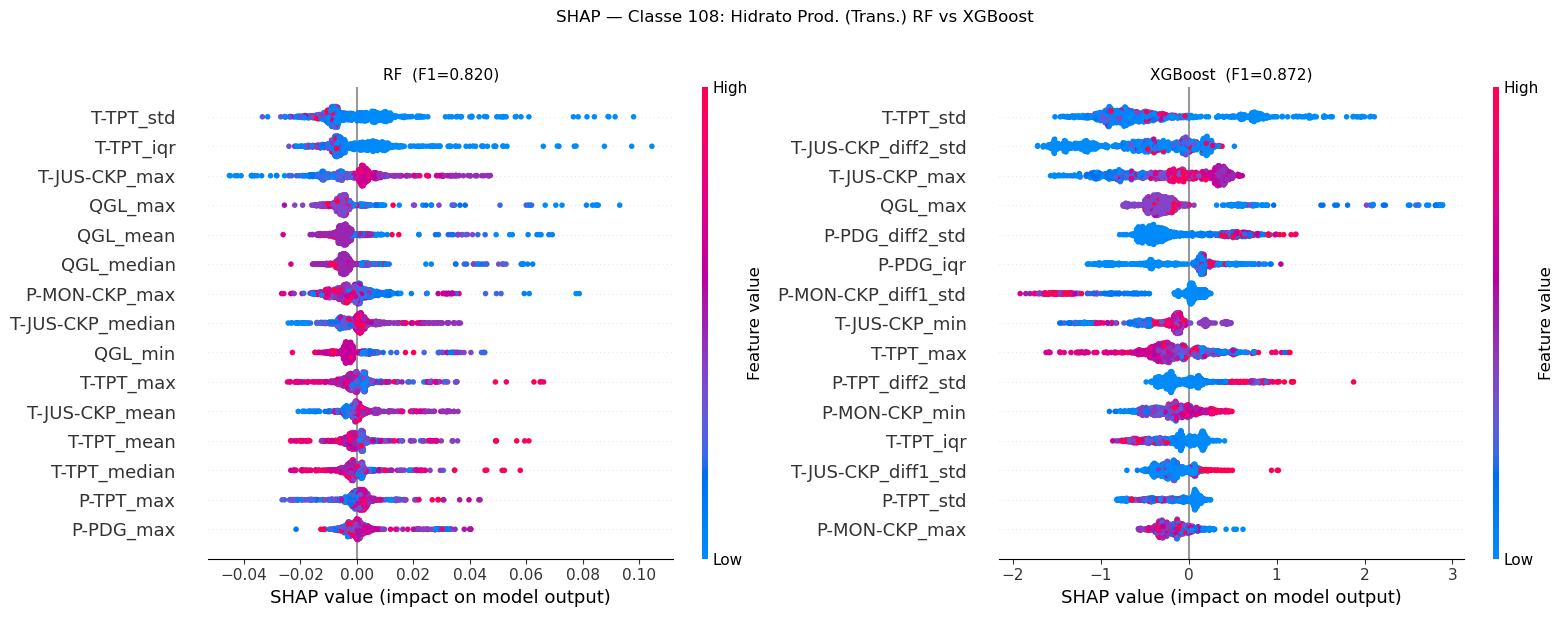

Classe  108 (Hidrato Prod. (Trans.)      ) RF=0.820  XGB=0.872  -> shap_classe108_rf_vs_xgboost.png


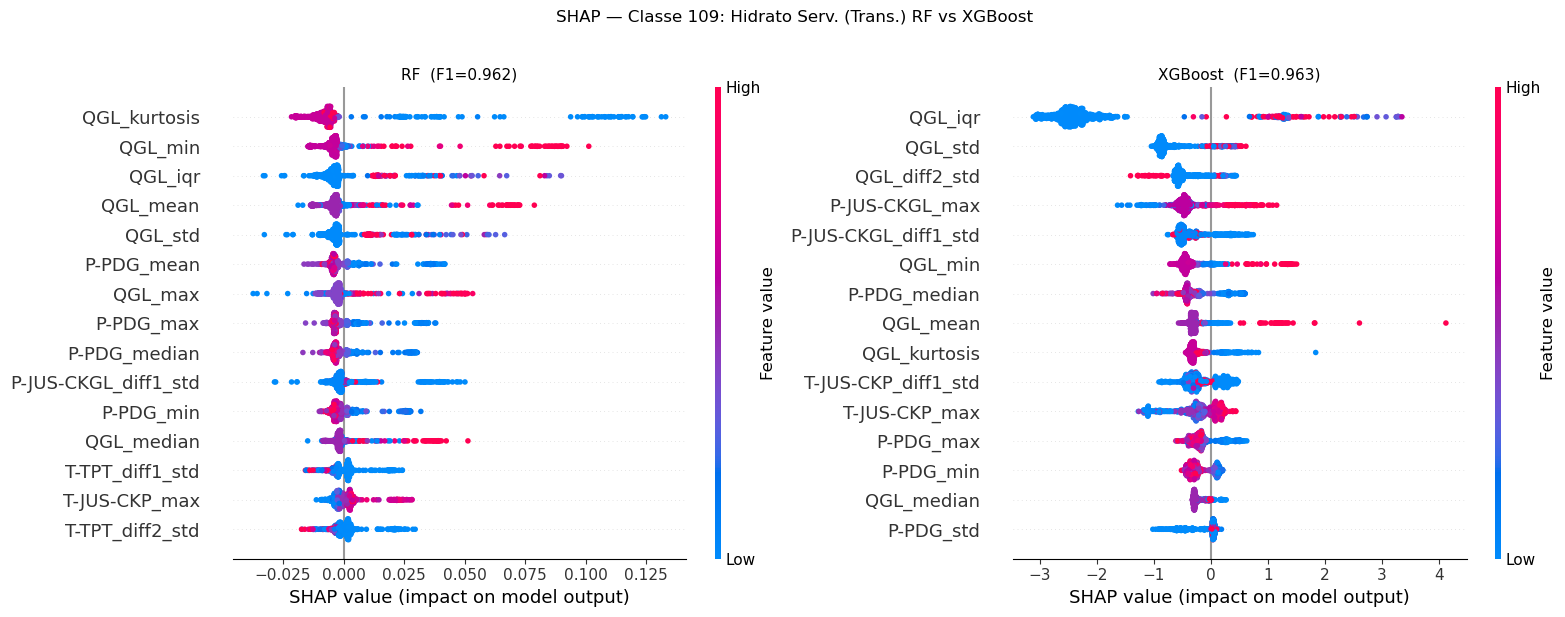

Classe  109 (Hidrato Serv. (Trans.)      ) RF=0.962  XGB=0.963  -> shap_classe109_rf_vs_xgboost.png


In [17]:
import json as _json
from config import METRICS_DIR

with open(METRICS_DIR / "rf_window_class_metrics.json") as _f:
    _rf_m = _json.load(_f)
with open(METRICS_DIR / "xgboost_window_class_metrics.json") as _f:
    _xgb_m = _json.load(_f)

f1_rf_class  = {int(k): v["f1"] for k, v in _rf_m["per_class"].items()}
f1_xgb_class = {int(k): v["f1"] for k, v in _xgb_m["per_class"].items()}

for orig_class in sorted(classes.tolist()):
    idx_c      = orig_to_idx[orig_class]
    class_name = WINDOW_CLASSES.get(orig_class, str(orig_class))
    f1_rf      = f1_rf_class.get(orig_class, float("nan"))
    f1_xgb     = f1_xgb_class.get(orig_class, float("nan"))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, sv, model_name, f1 in zip(
        axes,
        [shap_rf[:, :, idx_c], shap_xgb[:, :, idx_c]],
        ["RF", "XGBoost"],
        [f1_rf, f1_xgb],
    ):
        plt.sca(ax)
        shap.summary_plot(
            sv.values if hasattr(sv, "values") else sv,
            X_sample,
            feature_names=feature_cols,
            max_display=15,
            show=False,
            plot_size=None,
            color_bar=True,
        )
        ax.set_title(f"{model_name}  (F1={f1:.3f})", fontsize=11)

    plt.suptitle(
        f"SHAP — Classe {orig_class}: {class_name} RF vs XGBoost",
        fontsize=12, y=1.02
    )
    plt.tight_layout()
    fname = f"shap_classe{orig_class}_rf_vs_xgboost.png"
    fig.savefig(FIGURES_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Classe {orig_class:>4} ({class_name:<28}) RF={f1_rf:.3f}  XGB={f1_xgb:.3f}  -> {fname}")


---

## 6.8 Resumo — Figuras geradas

Todas salvas em :

| Arquivo | Conteúdo |
|---------|----------|
|  | MDI top-20 — RF vs XGBoost |
|  | SHAP barplot global — RF |
|  | Importância por sensor — RF vs XGBoost |
|  | SHAP classe 7 (PCK Incrustação) — RF vs XGBoost |
|  | SHAP classe 102 (DHSV Trans.) — RF vs XGBoost |
|  | SHAP todas as 17 classes — RF vs XGBoost |

---

## 6.9 Discussão — Interpretação Física

Complete esta tabela com base nos resultados obtidos acima:

| Feature mais importante | Sensor | O que representa fisicamente | Faz sentido para esse evento? |
|------------------------|--------|------------------------------|-------------------------------|
|  | Pressão no topo da árvore | Variabilidade de pressão | Sim — golfadas e hidratos causam oscilações |
|  | Pressão no topo | Velocidade de variação | Sim — fechamentos abruptos mudam pressão rápido |
|  | Vazão de gás lift | Nível médio de injeção | Sim — incrustação no PCK reduz a vazão efetiva |
| ... | ... | ... | ... |
